# Source A — What the Shape of an Article Knows

**The question:** how much of a county can be read off the *structure* of its
Wikipedia article — how many sections it has, how long they are, which ones are
present — without reading a word of the text?

**The prior:** the answer is "county size". `n_body_sections` was computed
during the section round, correlated r = 0.550 against log tax returns, and cut
from the scored block for exactly that reason. This notebook is built so that
prior can be checked rather than assumed: the size audit runs before the
scoring, and every arm sits on a baseline that already holds three size
measures.

**Read the baseline precisely.** It holds those three measures *linearly, in
logs*. So "lift over the baseline" means "beyond a linear-in-logs size model" —
not "beyond county size". Those are different claims, and until 2026-08-25 this
round made the stronger one. Part three carries a null-control arm built from
nothing but curves on the baseline's own columns, which is what makes the
difference measurable rather than arguable.

Every figure below is computed from committed artifacts. Nothing is typed in —
including the flexible-size-control results, which used to be quoted from the
branch review and are now a second baseline the sweep emits. The one number
quoted from outside the artifacts is the `r = 0.550` above, which is prior-round
history rather than a result of this one.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA, ANALYSIS, OUTPUTS = REPO / "data", REPO / "analysis-output", REPO / "outputs"
SOURCE_A = ANALYSIS / "source-a"

mpl.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 110, "axes.grid": True,
                     "axes.axisbelow": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

sections = pd.read_parquet(DATA / "source_a_sections.parquet")
features = pd.read_parquet(DATA / "source_a_structure_features.parquet")
feature_stats = json.loads((SOURCE_A / "source_a_structure_feature_stats.json").read_text())
scoring_stats = json.loads((SOURCE_A / "source_a_structure_stats.json").read_text())
scores = pd.read_csv(OUTPUTS / "source_a_structure_scores.csv")
by_pillar = pd.read_csv(OUTPUTS / "source_a_structure_by_pillar.csv")

print(f"{feature_stats['n_counties']:,} counties x {feature_stats['n_features']} structural features")
print(f"{len(sections):,} sections, {len(feature_stats['title_flag_vocabulary'])} title flags")

3,144 counties x 64 structural features
64,588 sections, 42 title flags


## Part one — what the corpus is shaped like

Three facts set up everything after them: how many sections an article has, how
unevenly its characters are spread across them, and how quickly the title
vocabulary thins out.

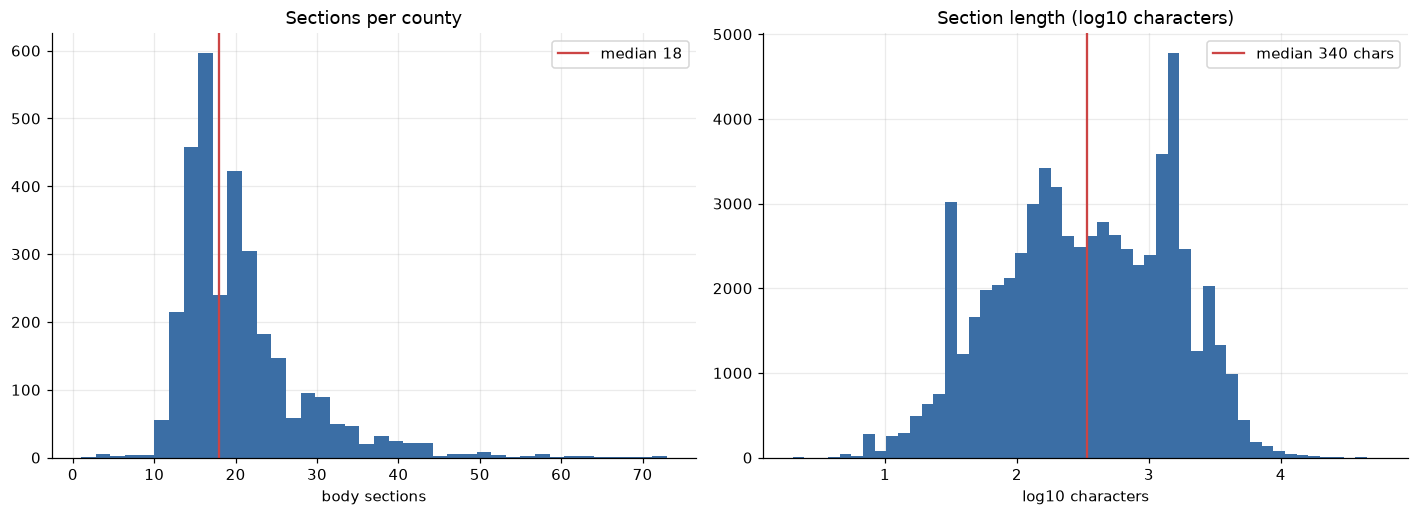

mean section length 848 chars, median 340, max 55,228
The mean sits well above the median: a handful of very long sections carry it.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(features["n_body_sections"], bins=40, color="#3b6ea5")
axes[0].set_title("Sections per county")
axes[0].set_xlabel("body sections")
axes[0].axvline(features["n_body_sections"].median(), color="#c44", lw=1.5,
                label=f"median {features['n_body_sections'].median():.0f}")
axes[0].legend()

section_chars = sections["section_text"].str.len()
axes[1].hist(np.log10(section_chars.clip(lower=1)), bins=50, color="#3b6ea5")
axes[1].set_title("Section length (log10 characters)")
axes[1].set_xlabel("log10 characters")
axes[1].axvline(np.log10(section_chars.median()), color="#c44", lw=1.5,
                label=f"median {section_chars.median():,.0f} chars")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"mean section length {section_chars.mean():,.0f} chars, median {section_chars.median():,.0f}, "
      f"max {section_chars.max():,.0f}")
print("The mean sits well above the median: a handful of very long sections carry it.")

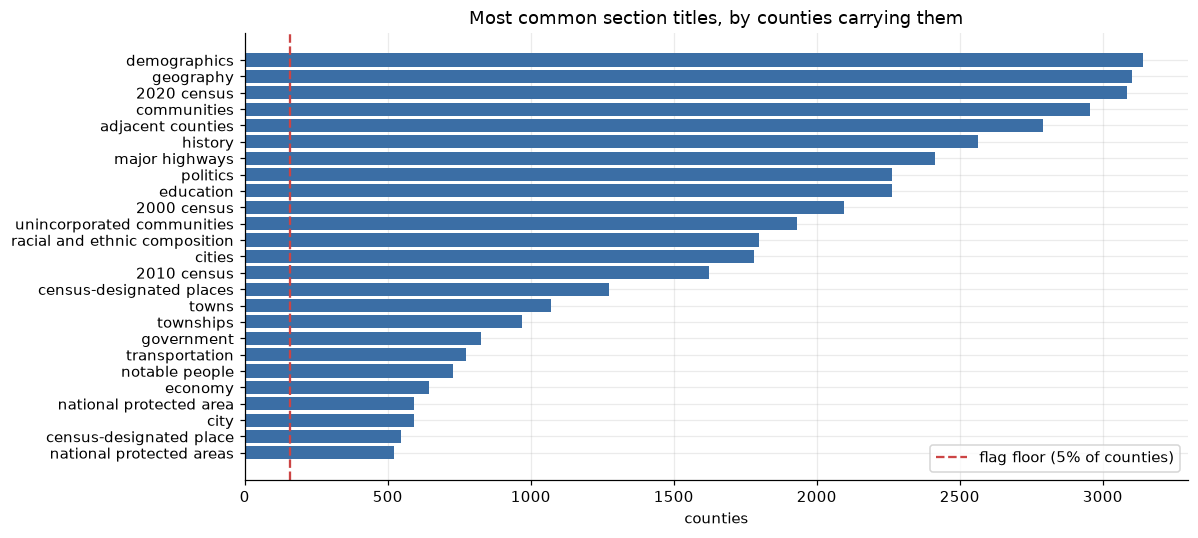

4,021 distinct titles; 42 clear the floor.


In [3]:
titles = sections["section_title"].fillna("").str.strip().str.lower()
per_title = titles[titles != ""].groupby(titles[titles != ""]).size().sort_values(ascending=False)
county_counts = (sections.assign(t=titles).loc[titles != ""]
                 .groupby("t")["fips_code"].nunique().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
top = county_counts.head(25)[::-1]
ax.barh(top.index, top.to_numpy(), color="#3b6ea5")
ax.axvline(feature_stats["title_flag_min_share"] * feature_stats["n_counties"], color="#c44",
           lw=1.5, ls="--", label=f"flag floor ({feature_stats['title_flag_min_share']:.0%} of counties)")
ax.set_title("Most common section titles, by counties carrying them")
ax.set_xlabel("counties")
ax.legend()
fig.tight_layout()
plt.show()

print(f"{len(county_counts):,} distinct titles; {len(feature_stats['title_flag_vocabulary'])} clear the floor.")

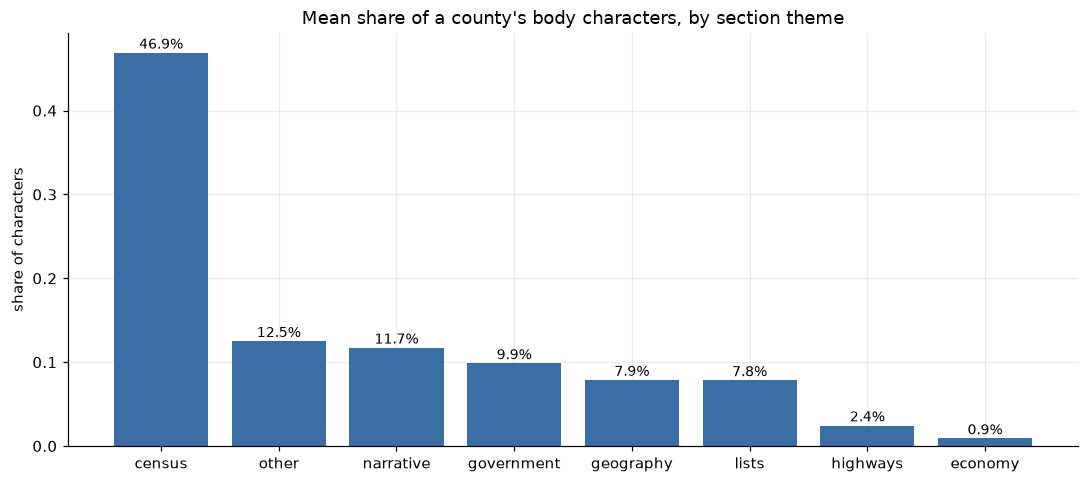

In [4]:
bucket_means = pd.Series(feature_stats["mean_bucket_share"]).sort_values(ascending=False)
bucket_means.index = [c.replace("share_chars_", "") for c in bucket_means.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(bucket_means.index, bucket_means.to_numpy(), color="#3b6ea5")
ax.set_title("Mean share of a county's body characters, by section theme")
ax.set_ylabel("share of characters")
for x, y in zip(bucket_means.index, bucket_means.to_numpy()):
    ax.text(x, y + 0.005, f"{y:.1%}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## Part two — the size-proxy audit

This runs before the scoring, on purpose: a structural column that is only a
size measurement in disguise has little left to contribute once a baseline
already holding three size measures has taken its share.

**Two diagnostics, because one of them is blind to the channel that matters.**
Pearson |r| against the three size features answers "is this column a *linear*
function of county size?" — and answering only that is how this round shipped a
false claim the first time. The baseline is linear in the logs, so what gets
through it is a *curved* relationship with size, and a near-deterministic curved
function of log population can sit at |r| = 0.04 and look clean. The second
diagnostic, `size_r2`, closes the gap: the out-of-fold R² of each structural
column regressed on a degree-3 polynomial basis in the same three size features,
five folds, seed 42. `linear_r2` is the same fit restricted to a straight line,
and `curve_gain` is the difference — what a curve on county size knows about
this column that a straight line does not. That last column is the one this
audit exists to show.

**And it comes back clean, which is not the same as safe.** No structural column
turns out to be a hidden curved size proxy: the strongest is explained about a
third of the way by a degree-3 size basis, and letting the fit curve buys very
little over a straight line anywhere in the block. That clears each column
*individually*. It does not clear the block — Part three's null control shows
the channel the scoring actually runs through works jointly across columns, at a
scale this per-column table cannot see. Take the clean audit as a necessary
condition for the round's claim, never a sufficient one.

**A near-constant column is not a column with headroom.** A flag that fires for
almost every county correlates weakly with everything, size included, because it
has almost no variance to correlate with. Sorting by |r| alone puts those at the
top of a "least size-dependent" list, where they read as if they had something
left to give. Prevalence and standard deviation sit beside the correlation below
so the two can be told apart, and the headroom table excludes flags firing on
more than 95% or fewer than 5% of counties.

Three size measures, not one: `n_body_sections` was cut on its correlation with
log tax returns specifically, and a table showing only population would have
understated it.

Every count, column name and range for this audit is printed by the cell that
computes it. None of it is typed into this prose — an audit result typed one
cell above the code that produces it is an audit result that rots silently the
next time the corpus moves.

In [5]:
import sys
sys.path.insert(0, str(REPO / "scripts"))
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from analyze_source_a_structure import N_FOLDS, RANDOM_SEED
from pillar_matrix import SIZE_FEATURES, build_matrix

matrix, _ = build_matrix()
merged = matrix[["fips_code", *SIZE_FEATURES]].merge(features, on="fips_code", how="inner")
structure_cols = [c for c in features.columns if c != "fips_code"]
values = merged[structure_cols]

# Diagnostic 1 — linear. What a correlation table can see.
correlations = pd.DataFrame({size: values.corrwith(merged[size]) for size in SIZE_FEATURES})
correlations["max_abs_r"] = correlations.abs().max(axis=1)

# Diagnostic 2 — nonlinear. Out-of-fold R² of each structural column against a
# degree-3 polynomial basis in the same three size measures. This is the one the
# baseline cannot control for, so it is the one that decides whether a lift is
# content or curvature.
size_basis = merged[list(SIZE_FEATURES)].to_numpy(dtype="float64")
block = values.to_numpy(dtype="float64")
folds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)


def size_explained(degree):
    """Out-of-fold R2 of every structural column against a size basis of this degree."""
    steps = [
        # Median-impute first, exactly as the scoring baseline does: `log_agi`
        # and `log_gdp_latest` are null for a handful of counties.
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
    if degree > 1:
        steps += [("expand", PolynomialFeatures(degree=degree, include_bias=False)),
                  ("rescale", StandardScaler())]
    steps.append(("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13), alpha_per_target=True)))
    predicted = cross_val_predict(Pipeline(steps), size_basis, block, cv=folds)
    return np.clip(r2_score(block, predicted, multioutput="raw_values"), 0.0, None)


correlations["linear_r2"] = size_explained(1)
correlations["size_r2"] = size_explained(3)
# The number that matters: what a *curve* on county size knows about this column
# that a straight line does not. That is the channel the baseline cannot control.
correlations["curve_gain"] = correlations["size_r2"] - correlations["linear_r2"]

# Variance, so "low |r|" and "nothing to correlate with" can be told apart.
correlations["sd"] = values.std()
is_flag = values.isin([0.0, 1.0]).all()
correlations["prevalence"] = values.mean().where(is_flag)
near_constant = (correlations["prevalence"].fillna(0.5) - 0.5).abs() > 0.45

shown = ["max_abs_r", "linear_r2", "size_r2", "curve_gain", "sd", "prevalence"]
correlations = correlations.sort_values("size_r2", ascending=False)
near_constant = near_constant.reindex(correlations.index)  # keep the mask in table order

print("Most size-dependent structural columns, by the nonlinear measure:")
display(correlations[[*SIZE_FEATURES, *shown]].head(12).round(3))

print("\nLargest curvature gain — where a curve on size beats a straight line by most:")
display(correlations.nlargest(8, "curve_gain")[shown].round(3))

headroom = correlations.loc[~near_constant].nsmallest(12, "size_r2")
print("\nLeast size-dependent — the columns with headroom, near-constant flags excluded:")
display(headroom[[*SIZE_FEATURES, *shown]].round(3))

print("\nNear-constant flags excluded from that table, and why they are not headroom:")
display(correlations.loc[near_constant, shown].sort_values("prevalence", ascending=False).round(3))

Most size-dependent structural columns, by the nonlinear measure:


,log_population,log_agi,log_gdp_latest,max_abs_r,linear_r2,size_r2,curve_gain,sd,prevalence
n_body_sections,0.546,0.546,0.543,0.546,0.302,0.340,0.038,7.789,NaN
max_section_id,0.545,0.544,0.541,0.545,0.300,0.338,0.038,7.968,NaN
n_distinct_titles,0.548,0.549,0.545,0.549,0.304,0.334,0.030,6.906,NaN
total_body_chars,0.425,0.433,0.447,0.447,0.191,0.268,0.076,15768.085,NaN
share_chars_census,-0.465,-0.457,-0.438,0.465,0.214,0.220,0.005,0.188,NaN
share_in_largest_section,-0.434,-0.426,-0.425,0.434,0.186,0.197,0.011,0.078,NaN
share_chars_other,0.392,0.390,0.376,0.392,0.153,0.182,0.028,0.137,NaN
share_stub_sections,-0.360,-0.370,-0.382,0.382,0.137,0.149,0.012,0.125,NaN
has_section_transportation,0.374,0.378,0.371,0.378,0.142,0.149,0.007,0.430,0.246
mean_section_chars,0.282,0.294,0.324,0.324,0.096,0.139,0.043,332.405,NaN



Largest curvature gain — where a curve on size beats a straight line by most:


,max_abs_r,linear_r2,size_r2,curve_gain,sd,prevalence
total_body_chars,0.447,0.191,0.268,0.076,15768.085,NaN
n_untitled_sections,0.299,0.086,0.135,0.049,1.944,NaN
mean_section_chars,0.324,0.096,0.139,0.043,332.405,NaN
has_section_geography,0.115,0.018,0.058,0.040,0.113,0.987
n_body_sections,0.546,0.302,0.340,0.038,7.789,NaN
max_section_id,0.545,0.300,0.338,0.038,7.968,NaN
n_distinct_titles,0.549,0.304,0.334,0.030,6.906,NaN
share_chars_other,0.392,0.153,0.182,0.028,0.137,NaN



Least size-dependent — the columns with headroom, near-constant flags excluded:


,log_population,log_agi,log_gdp_latest,max_abs_r,linear_r2,size_r2,curve_gain,sd,prevalence
has_section_2000_census,-0.072,-0.080,-0.061,0.080,0.007,0.0,-0.007,0.472,0.666
share_chars_geography,-0.130,-0.115,-0.115,0.130,0.019,0.0,-0.019,0.050,NaN
share_chars_economy,0.149,0.144,0.164,0.164,0.025,0.0,-0.025,0.025,NaN
share_chars_lists,-0.016,-0.007,-0.042,0.042,0.007,0.0,-0.007,0.048,NaN
has_section_ghost_towns,-0.056,-0.050,-0.023,0.056,0.006,0.0,-0.006,0.331,0.126
has_section_railroads,0.113,0.115,0.098,0.115,0.009,0.0,-0.009,0.226,0.054
has_section_racial_and_ethnic_composition,0.187,0.171,0.158,0.187,0.035,0.0,-0.035,0.495,0.572
has_section_transit,0.076,0.080,0.092,0.092,0.008,0.0,-0.008,0.249,0.066
has_section_climate_and_weather,0.033,0.041,0.025,0.041,0.003,0.0,-0.003,0.250,0.067
has_section_lakes,-0.118,-0.083,-0.079,0.118,0.033,0.0,-0.033,0.252,0.068



Near-constant flags excluded from that table, and why they are not headroom:


,max_abs_r,linear_r2,size_r2,curve_gain,sd,prevalence
has_section_demographics,0.018,0.000,0.000,0.000,0.031,0.999
has_section_geography,0.115,0.018,0.058,0.040,0.113,0.987
has_section_2020_census,0.129,0.014,0.031,0.017,0.137,0.981


LINEAR: 6 of 64 columns clear |r| = 0.4 against at least one size measure — n_body_sections, max_section_id, n_distinct_titles, total_body_chars, share_chars_census, share_in_largest_section.
The remaining 58 do not sit at a cliff edge: 3 land between 0.35 and 0.40 (share_chars_other, share_stub_sections, has_section_transportation), 11 are above 0.30, and the twelve weakest span |r| = 0.018–0.087.
3 columns are near-constant flags (>95% or <5% prevalence): has_section_geography, has_section_2020_census, has_section_demographics. Sorted by |r| alone they lead the 'least size-dependent' list — but their low |r| is missing variance, not spare information, so they are excluded from the headroom table above.

NONLINEAR: no structural column is a near-deterministic function of county size in any shape. The largest out-of-fold R² on a degree-3 size basis is 0.340 (n_body_sections); 5 columns clear 0.20 and 12 clear 0.10.
0 columns hide behind the linear diagnostic (|r| < 0.4 but size_r2 > 0.

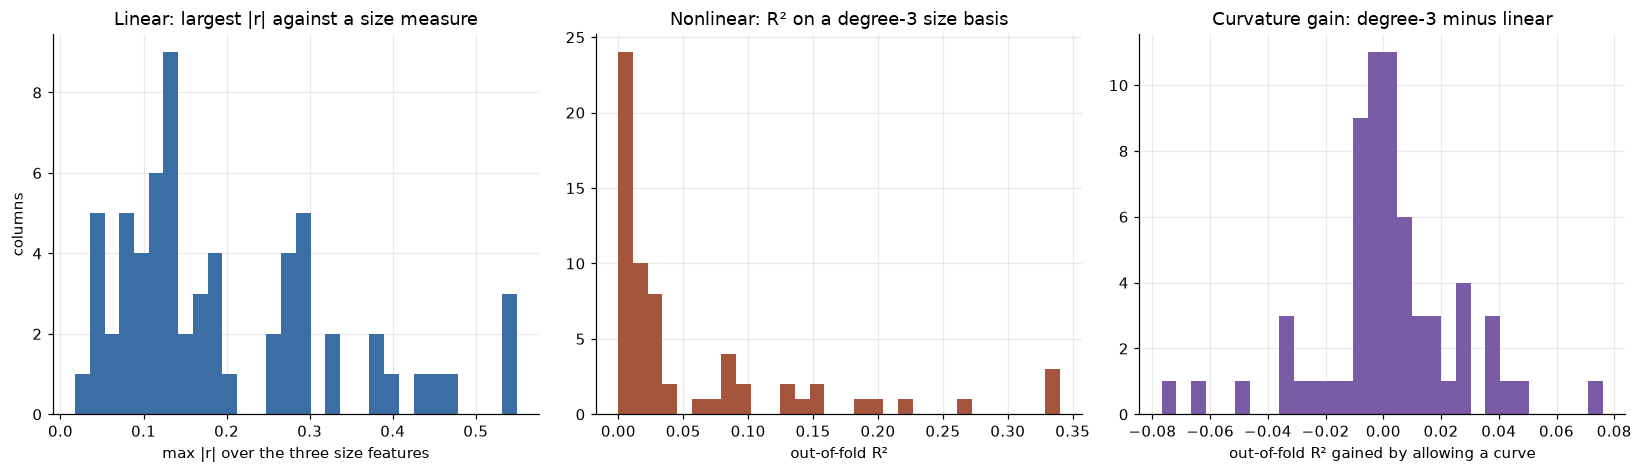

In [6]:
strong = correlations.index[correlations["max_abs_r"] > 0.4].tolist()
near_line = correlations.index[
    correlations["max_abs_r"].between(0.35, 0.4, inclusive="left")
].tolist()
weakest = correlations.nsmallest(12, "max_abs_r")["max_abs_r"]

print(f"LINEAR: {len(strong)} of {len(correlations)} columns clear |r| = 0.4 against at least one "
      f"size measure — {', '.join(strong)}.")
print(f"The remaining {len(correlations) - len(strong)} do not sit at a cliff edge: "
      f"{len(near_line)} land between 0.35 and 0.40 ({', '.join(near_line) or 'none'}), "
      f"{int((correlations['max_abs_r'] > 0.3).sum())} are above 0.30, and the twelve weakest "
      f"span |r| = {weakest.min():.3f}–{weakest.max():.3f}.")
print(f"{int(near_constant.sum())} columns are near-constant flags (>95% or <5% prevalence): "
      f"{', '.join(correlations.index[near_constant])}. Sorted by |r| alone they lead the "
      f"'least size-dependent' list — but their low |r| is missing variance, not spare "
      f"information, so they are excluded from the headroom table above.")

top_curve = correlations.nlargest(1, "curve_gain").iloc[0]
hidden = correlations[(correlations["max_abs_r"] < 0.4) & (correlations["size_r2"] > 0.4)]
print(f"\nNONLINEAR: no structural column is a near-deterministic function of county size in "
      f"any shape. The largest out-of-fold R² on a degree-3 size basis is "
      f"{correlations['size_r2'].max():.3f} ({correlations['size_r2'].idxmax()}); "
      f"{int((correlations['size_r2'] > 0.2).sum())} columns clear 0.20 and "
      f"{int((correlations['size_r2'] > 0.1).sum())} clear 0.10.")
print(f"{len(hidden)} columns hide behind the linear diagnostic (|r| < 0.4 but size_r2 > 0.4): "
      f"{', '.join(hidden.index) or 'none'}.")
print(f"Curvature adds little per column: the largest gain over a straight-line fit is "
      f"{top_curve['curve_gain']:+.3f} ({correlations['curve_gain'].idxmax()}), and the median "
      f"gain is {correlations['curve_gain'].median():+.3f}.")
print("\nRead that carefully: it clears each column INDIVIDUALLY, not the block. The null-control")
print("arm in Part three shows the size channel this block runs through operates jointly across")
print("columns and at a scale no per-column audit here can see. A clean audit is a necessary")
print("condition for the round's claim, not a sufficient one.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].hist(correlations["max_abs_r"], bins=30, color="#3b6ea5")
axes[0].set_title("Linear: largest |r| against a size measure")
axes[0].set_xlabel("max |r| over the three size features")
axes[0].set_ylabel("columns")
axes[1].hist(correlations["size_r2"], bins=30, color="#a5553b")
axes[1].set_title("Nonlinear: R² on a degree-3 size basis")
axes[1].set_xlabel("out-of-fold R²")
axes[2].hist(correlations["curve_gain"], bins=30, color="#7a5ba5")
axes[2].set_title("Curvature gain: degree-3 minus linear")
axes[2].set_xlabel("out-of-fold R² gained by allowing a curve")
fig.tight_layout()
plt.show()

## Part three — the arms, and the null control that prices them

Every arm sits on the same unpenalized baseline of three size measures plus
state fixed effects, and is fitted to that baseline's residuals with a ridge
whose penalty is chosen by nested crossvalidation. Identical folds, identical
rows, five folds, seed 42. A block of pure noise therefore costs approximately
nothing rather than dragging the controls down.

**A block of pure *curvature* does not cost approximately nothing, and that is
the whole story of this round.** The `size_nonlinear` arm is a null control: nine
columns of squares, cubes and pairwise products of `log_population`, `log_agi`
and `log_gdp_latest` — the baseline's own three columns, reshaped. It contains no
information the baseline does not already hold. It is in the table below because
the number it scores is the unit every other number should be read in.

In [7]:
arms = pd.DataFrame(scoring_stats["arms"]).T
display(arms[["label", "compared_against", "mean_lift", "mean_paired_difference", "n_wins", "wilcoxon_p"]])

null_key = scoring_stats["null_arm_key"]
null_arm, structure_arm = scoring_stats["arms"][null_key], scoring_stats["arms"]["structure"]
fusion = scoring_stats["arms"]["typed_plus_structure"]

print(f"{scoring_stats['n_targets']} targets | "
      f"{scoring_stats['n_structure_features']} structural columns vs "
      f"{scoring_stats['n_typed_features']} shipped typed columns vs "
      f"{scoring_stats['n_size_nonlinear_features']} null columns")
print(f"\nNULL CONTROL '{null_key}' carries zero information the baseline lacks, and scores "
      f"{null_arm['mean_lift']:+.5f} on {null_arm['n_wins']}/{scoring_stats['n_targets']} targets "
      f"(p={null_arm['wilcoxon_p']:.2g}).")
ratio = scoring_stats["structure_lift_in_null_arm_units"]
if ratio:
    print(f"The structural arm's {structure_arm['mean_lift']:+.5f} is {ratio:.2f}x that — "
          f"{1 / ratio:.1f} times SMALLER than an information-free reshaping of the controls.")
else:
    print(f"The structural arm scores {structure_arm['mean_lift']:+.5f}; the null arm scores "
          f"{null_arm['mean_lift']:+.5f}, too close to zero to express one as a multiple of "
          f"the other.")
print("So a positive lift here means 'beyond a LINEAR-in-logs size model'. It does not mean "
      "'beyond county size'.")

,label,compared_against,mean_lift,mean_paired_difference,n_wins,wilcoxon_p
structure,structural block (shape only),baseline,0.002686,0.002686,21,0.001172
typed,shipped 29 typed columns,baseline,0.003072,0.003072,22,0.000381
typed_plus_structure,typed columns + structural block,typed,0.004908,0.001836,20,0.011839
size_nonlinear,NULL CONTROL: nonlinear transforms of the base...,baseline,0.017478,0.017478,26,0.000001


28 targets | 64 structural columns vs 29 shipped typed columns vs 9 null columns

NULL CONTROL 'size_nonlinear' carries zero information the baseline lacks, and scores +0.01748 on 26/28 targets (p=1.3e-06).
The structural arm's +0.00269 is 0.15x that — 6.5 times SMALLER than an information-free reshaping of the controls.
So a positive lift here means 'beyond a LINEAR-in-logs size model'. It does not mean 'beyond county size'.


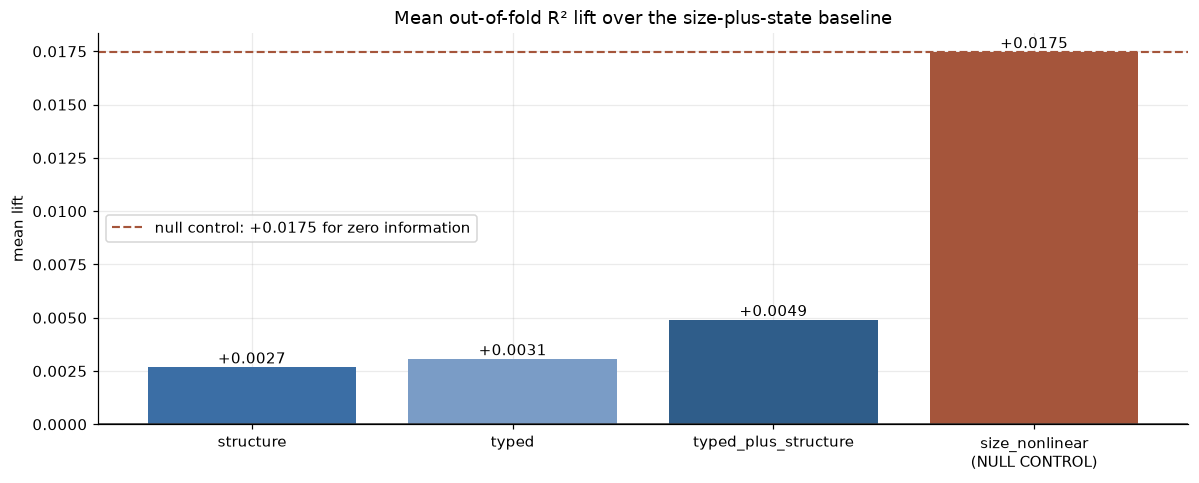

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
keys = list(scoring_stats["arms"])
values = [scoring_stats["arms"][k]["mean_lift"] for k in keys]
# The null arm is drawn in a different colour, and named as one on the axis, so
# it cannot be skim-read as a fourth result.
palette = {"structure": "#3b6ea5", "typed": "#7a9cc6", "typed_plus_structure": "#2f5d8a"}
ax.bar(keys, values, color=[palette.get(k, "#a5553b") for k in keys])
ax.axhline(0, color="#333", lw=1)
ax.axhline(null_arm["mean_lift"], color="#a5553b", lw=1.4, ls="--",
           label=f"null control: {null_arm['mean_lift']:+.4f} for zero information")
ax.set_title("Mean out-of-fold R² lift over the size-plus-state baseline")
ax.set_ylabel("mean lift")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels([f"{k}\n(NULL CONTROL)" if k == null_key else k for k in keys])
ax.legend()
for x, y in zip(keys, values):
    ax.text(x, y, f"{y:+.4f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=10)
fig.tight_layout()
plt.show()

### Per-pillar, because the aggregate is a property of the basket

Twenty of the twenty-eight targets are one QCEW table. A basket-wide mean is
therefore 71% one pillar, and reading it as a breadth claim is a mistake this
project has made before.

,pillar,n_targets,structure,typed,typed_plus_structure,size_nonlinear,structure_flexbase,typed_flexbase,typed_plus_structure_flexbase,size_nonlinear_flexbase
0,B,20,0.00314,0.00244,0.00497,0.02010,0.00086,0.00162,0.00284,0.0
1,C,3,0.00130,0.00180,0.00298,0.00177,0.00065,0.00100,0.00194,0.0
2,D,3,0.00000,0.00153,0.00079,0.02107,0.00000,0.00102,0.00021,0.0
3,E,1,0.00179,0.00530,0.00447,0.00001,0.00075,0.00311,0.00272,0.0
4,F,1,0.00671,0.02182,0.02217,0.01892,0.00061,0.00347,0.00574,-0.0


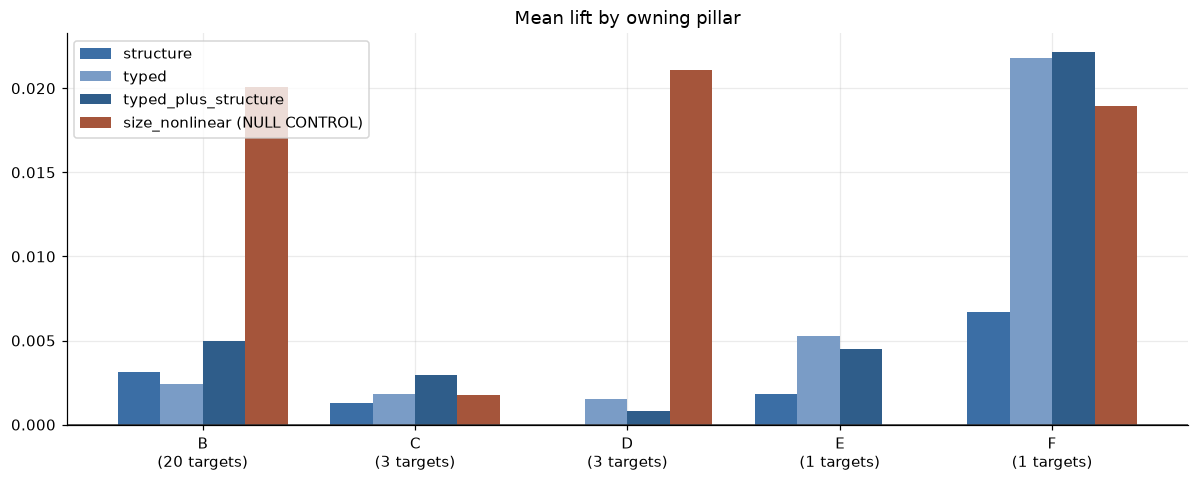

In [9]:
display(by_pillar.round(5))

fig, ax = plt.subplots(figsize=(11, 4.5))
width = 0.8 / len(keys)
x = np.arange(len(by_pillar))
offsets = (np.arange(len(keys)) - (len(keys) - 1) / 2) * width
for offset, key in zip(offsets, keys):
    label = f"{key} (NULL CONTROL)" if key == null_key else key
    ax.bar(x + offset, by_pillar[key], width, label=label, color=palette.get(key, "#a5553b"))
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({n} targets)" for p, n in zip(by_pillar["pillar"], by_pillar["n_targets"])])
ax.axhline(0, color="#333", lw=1)
ax.set_title("Mean lift by owning pillar")
ax.legend()
fig.tight_layout()
plt.show()

In [10]:
best = scores.head(10)[["pillar", "label", "n", "r2_baseline", "lift_structure", "lift_typed",
                        "lift_typed_plus_structure", "lift_size_nonlinear"]]
print("Targets where article shape helps most — with the null arm on the same rows:")
display(best.round(4))

worst = scores.tail(5)[["pillar", "label", "lift_structure", "lift_typed", "lift_size_nonlinear"]]
print("\nAnd where it hurts most:")
display(worst.round(4))

beaten = scores[scores["lift_size_nonlinear"] > scores["lift_structure"]]
print(f"\nOn {len(beaten)} of {len(scores)} targets the information-free null block beats the "
      f"structural block outright.")

Targets where article shape helps most — with the null arm on the same rows:


,pillar,label,n,r2_baseline,lift_structure,lift_typed,lift_typed_plus_structure,lift_size_nonlinear
0,B,Accommodation & Food Services LQ,2369,0.1273,0.0255,0.0253,0.0478,0.0248
1,B,Retail Trade LQ,3050,0.1118,0.0103,-0.0014,0.0056,0.0496
2,F,demographic distress count,3144,0.2017,0.0067,0.0218,0.0222,0.0189
3,B,Manufacturing LQ,2570,0.2153,0.0060,0.0058,0.0091,0.0000
4,B,"Agriculture, Forestry, Fishing & Hunting LQ",1457,0.3362,0.0047,0.0004,0.0048,0.0373
5,B,Educational Services LQ,1587,0.1161,0.0037,0.0001,0.0029,0.0065
6,B,Information LQ,1914,0.0344,0.0037,0.0028,0.0078,0.0871
7,C,unemployment rate (level),3143,0.5028,0.0034,0.0036,0.0063,0.0000
8,B,Wholesale Trade LQ,2346,0.2191,0.0033,0.0021,0.0049,0.0361
9,B,"Arts, Entertainment & Recreation LQ",2243,0.1706,0.0029,0.0017,0.0043,0.0000



And where it hurts most:


,pillar,label,lift_structure,lift_typed,lift_size_nonlinear
23,B,Construction LQ,-0.0004,0.0002,0.0000
24,B,Real Estate & Rental & Leasing LQ,-0.0004,0.0023,0.0000
25,B,Transportation & Warehousing LQ,-0.0006,0.0057,-0.0004
26,B,Administrative & Support & Waste Management LQ,-0.0011,-0.0009,0.0000
27,B,Finance & Insurance LQ,-0.0022,0.0040,0.0652



On 19 of 28 targets the information-free null block beats the structural block outright.


### What survives, and what does not

The structural arm's lift is not noise — its Wilcoxon test, printed with the
arms table above, is not a fluke. It is *not* real in the sense the round
originally claimed. Three things follow, and they have to be read together.

1. **Lift here is measured against a linear-in-logs size model, not against
   county size.** The null-control arm above settles that: an information-free
   reshaping of the baseline's own three columns scores several times the
   structural block. Curvature in the relationship between an article's shape
   and a county's size clears this bar while carrying no content at all.
2. **So the honest test is a size control that knows the *shape* of the size
   relationship, not just its level.** The sweep now runs one: the same nine
   nonlinear terms, residualized against the three linear size columns and
   SVD-whitened, appended to the baseline design rather than scored as an arm.
   It is a second *baseline*, not a fifth arm — an arm competes with the
   controls, an augmentation joins them, and only the second can answer "how
   much of this lift was functional form?" Being information-free, it barely
   moves mean baseline R². Every arm is scored against both.
3. **The null arm is what proves the augmentation works.** `size_nonlinear`
   scores several times the structural block against the linear baseline and
   essentially zero against the flexible one — the cell below prints both. The
   flexible baseline absorbs the null arm exactly, which is what it must do if
   that lift was curvature and nothing else.

Two further controls — 64 columns of Gaussian noise in the arm slot, and a
rescore of the block with the six flagged size-proxy columns dropped — were run
during the branch review and have no artifact in this repository. They are
recorded with their numbers and their provenance in
`analysis-output/source-a/source-a-findings.md` §23.3 and §23.4, and are
deliberately not quoted here: every figure on this page comes from a committed
artifact, and these two would be the exceptions.

In [11]:
flex, flex_ok = scoring_stats["arms_flexible"], scoring_stats["arms_flexible_undegraded"]
retention = scoring_stats["flexible_retention"]

print(f"FLEXIBLE BASELINE: {scoring_stats['n_flexible_directions']} whitened curvature directions, "
      f"carrying no information. Mean baseline R² {scoring_stats['mean_r2_baseline']:.4f} → "
      f"{scoring_stats['mean_r2_baseline_flexible']:.4f} — it buys the controls almost nothing, "
      f"which is the point.\n")

comparison = pd.DataFrame({
    "as shipped (linear baseline)": {
        k: f"{v['mean_paired_difference']:+.5f}, {v['n_wins']}/{v['n_targets']}, p={v['wilcoxon_p']:.4f}"
        for k, v in scoring_stats["arms"].items()},
    "+ flexible size": {
        k: f"{v['mean_paired_difference']:+.5f}, {v['n_wins']}/{v['n_targets']}, p={v['wilcoxon_p']:.4f}"
        for k, v in flex.items()},
    "retained": {k: ("—" if v is None else f"{v:.0%}") for k, v in retention.items()},
    "vs": {k: v["compared_against"] for k, v in scoring_stats["arms"].items()},
})
display(comparison)

for key in ("structure", "typed"):
    print(f"{key}: {scoring_stats['arms'][key]['mean_paired_difference']:+.5f} → "
          f"{flex[key]['mean_paired_difference']:+.5f} "
          f"({flex[key]['n_wins']}/{flex[key]['n_targets']}, p={flex[key]['wilcoxon_p']:.4f}), "
          f"retaining {retention[key]:.0%}.")

fusion = flex["typed_plus_structure"]
verdict = "does NOT survive" if fusion["wilcoxon_p"] > 0.05 else "survives"
print(f"\nFUSION — typed_plus_structure over typed — {verdict} the flexible control: "
      f"{scoring_stats['arms']['typed_plus_structure']['mean_paired_difference']:+.5f} "
      f"(p={scoring_stats['arms']['typed_plus_structure']['wilcoxon_p']:.4f}) → "
      f"{fusion['mean_paired_difference']:+.5f} (p={fusion['wilcoxon_p']:.4f}).")
print("That was the one comparison that could have argued for shipping these columns.")

null_flex = flex[null_key]
print(f"\nAND THE NULL ARM VALIDATES THE AUGMENTATION: {null_key} scores "
      f"{null_arm['mean_lift']:+.5f} against the linear baseline and "
      f"{null_flex['mean_lift']:+.5f} (p={null_flex['wilcoxon_p']:.4f}) against the flexible one. "
      f"The augmentation absorbs it exactly.")

FLEXIBLE BASELINE: 9 whitened curvature directions, carrying no information. Mean baseline R² 0.2612 → 0.2607 — it buys the controls almost nothing, which is the point.



,as shipped (linear baseline),+ flexible size,retained,vs
structure,"+0.00269, 21/28, p=0.0012","+0.00073, 20/28, p=0.0281",27%,baseline
typed,"+0.00307, 22/28, p=0.0004","+0.00161, 18/28, p=0.0110",52%,baseline
typed_plus_structure,"+0.00184, 20/28, p=0.0118","+0.00095, 18/28, p=0.1315",52%,typed
size_nonlinear,"+0.01748, 26/28, p=0.0000","+0.00000, 15/28, p=0.1128",0%,baseline


structure: +0.00269 → +0.00073 (20/28, p=0.0281), retaining 27%.
typed: +0.00307 → +0.00161 (18/28, p=0.0110), retaining 52%.

FUSION — typed_plus_structure over typed — does NOT survive the flexible control: +0.00184 (p=0.0118) → +0.00095 (p=0.1315).
That was the one comparison that could have argued for shipping these columns.

AND THE NULL ARM VALIDATES THE AUGMENTATION: size_nonlinear scores +0.01748 against the linear baseline and +0.00000 (p=0.1128) against the flexible one. The augmentation absorbs it exactly.


#### Why the same nine terms are worth a large lift as an arm and ~nothing as a baseline

These two facts look contradictory and are not. As an *arm* the terms are fitted
to the baseline's residuals by a ridge whose penalty is chosen by nested
crossvalidation, which extracts the little signal they carry efficiently. As a
*baseline augmentation* they enter an unpenalized OLS fit alongside three size
columns they are nearly collinear with, where the same nine directions are
estimated noisily and mostly overfitted away — which is why mean baseline R²
barely moves, and why the augmentation degrades some targets outright. Both
readings are correct, and together they are the strongest evidence in this round
that the null arm's lift is curvature: only a curvature-shaped control can
absorb it.

In [12]:
degraded = scoring_stats["flexible_degraded_targets"]
print(f"The flexible baseline degrades on {scoring_stats['n_targets_flexible_degraded']} of "
      f"{scoring_stats['n_targets']} targets from that OLS instability: {', '.join(degraded)}.")
print(f"On those targets a 'lift over the baseline' is measured against a goalpost that moved, "
      f"so the {scoring_stats['n_targets_flexible_undegraded']} undegraded targets are reported "
      f"beside the full basket rather than instead of it:\n")

restricted = pd.DataFrame({
    "all targets": {k: f"{v['mean_paired_difference']:+.5f}, {v['n_wins']}/{v['n_targets']}, "
                       f"p={v['wilcoxon_p']:.4f}" for k, v in flex.items()},
    "undegraded only": {k: f"{v['mean_paired_difference']:+.5f}, {v['n_wins']}/{v['n_targets']}, "
                           f"p={v['wilcoxon_p']:.4f}" for k, v in flex_ok.items()},
})
display(restricted)

worse = [k for k in flex if flex_ok[k]["wilcoxon_p"] > 0.05 >= flex[k]["wilcoxon_p"]]
if worse:
    print(f"Restricting to the undegraded targets costs significance for: {', '.join(worse)}. "
          f"The restricted reading is the more conservative one and is not the headline only "
          f"because it discards six targets on a criterion the baseline, not the arm, failed.")

The flexible baseline degrades on 6 of 28 targets from that OLS instability: capital_to_wage_ratio, distress_count, lq_emp_31-33, out_partner_hhi, unemployment_rate_latest, unemployment_velocity.
On those targets a 'lift over the baseline' is measured against a goalpost that moved, so the 22 undegraded targets are reported beside the full basket rather than instead of it:



,all targets,undegraded only
structure,"+0.00073, 20/28, p=0.0281","+0.00062, 15/22, p=0.2099"
typed,"+0.00161, 18/28, p=0.0110","+0.00148, 13/22, p=0.1289"
typed_plus_structure,"+0.00095, 18/28, p=0.1315","+0.00091, 14/22, p=0.2902"
size_nonlinear,"+0.00000, 15/28, p=0.1128","+0.00000, 10/22, p=0.5202"


Restricting to the undegraded targets costs significance for: structure, typed. The restricted reading is the more conservative one and is not the headline only because it discards six targets on a criterion the baseline, not the arm, failed.


#### Where the surviving lift lives

The collapse is not uniform. It lands hardest on the targets that carried the
headline, and one target holds most of its value — which is the publishable
result this round actually produces.

In [13]:
survival = scores[["label", "lift_structure", "lift_structure_flexbase"]].copy()
survival["retained"] = survival["lift_structure_flexbase"] / survival["lift_structure"]
survival = survival[survival["lift_structure"] > 0.001].sort_values(
    "lift_structure", ascending=False)
display(survival.set_index("label").round(5))

best = survival.iloc[0]
print(f"{best['label']} retains {best['lift_structure_flexbase']:+.5f} of "
      f"{best['lift_structure']:+.5f} ({best['retained']:.0%}) — far more than any other target, "
      f"and more than the whole-basket retention of {retention['structure']:.0%}.")
print(f"A county's article shape carrying real signal about its accommodation-and-food location "
      f"quotient, net of a flexible size model, is a publishable result.")
print(f'"The shape of an article knows things county size does not" is not.')

,lift_structure,lift_structure_flexbase,retained
label,,,
Accommodation & Food Services LQ,0.02546,0.01203,0.47241
Retail Trade LQ,0.01031,0.00084,0.08190
demographic distress count,0.00671,0.00061,0.09063
Manufacturing LQ,0.00600,0.00356,0.59396
"Agriculture, Forestry, Fishing & Hunting LQ",0.00467,0.00006,0.01351
Educational Services LQ,0.00369,0.00050,0.13692
Information LQ,0.00366,0.00008,0.02101
unemployment rate (level),0.00337,0.00190,0.56390
Wholesale Trade LQ,0.00325,0.00107,0.32947


Accommodation & Food Services LQ retains +0.01203 of +0.02546 (47%) — far more than any other target, and more than the whole-basket retention of 27%.
A county's article shape carrying real signal about its accommodation-and-food location quotient, net of a flexible size model, is a publishable result.
"The shape of an article knows things county size does not" is not.


## What this round does and does not settle

- It does not propose shipping these columns. `typed_plus_structure` beats
  `typed` against the linear baseline, but that comparison does not survive the
  flexible size control — see the fusion line printed above — so there is no
  fusion case to make.
- It reads no section text. Any lexicon question belongs to the section-scope
  round, which already exists.
- It does not revisit the `n_body_sections` cut on its own authority. Nothing
  above argues for reopening it; the audit's nonlinear diagnostic argues the
  other way.
- The open question it leaves is Accommodation & Food Services: the one target
  where article shape retains most of its lift under the flexible size control,
  and the one worth a round of its own.